# Mindtune EEG — 3-Class Emotion Classifier

**Goal**: Predict `calm / neutral / stressed` from `model_ready.csv`.

This notebook is aligned to the columns you have in `model_ready.csv`:
- Band-power **percent features** (`*_pct`)
- Optional: `attention`, `meditation`, `signal_quality`
- Event flags: `marker_ev_*_active`

## Notes
- We avoid SMOTE here to keep dependencies simple and prevent leakage bugs.
- We use **GroupCV by `session_id`** (sessions don’t leak between train/test folds).
- We optimize and report **macro‑F1** (better than accuracy for imbalanced 3‑class).

### Why you might see “~50% accuracy”
Your labels are **imbalanced** (~52% *stressed*). Two different numbers appear in the benchmarks:

- **`acc` (standard accuracy)** — how often the predicted label matches the true label. A strong majority-class baseline is **~52%** (always guess *stressed*). A useful model should beat that by several points (often **~58–62%** here, depending on the estimator).
- **`bal-acc` (balanced accuracy)** — average of per-class **recall**. For hard classes (especially *calm*), this often sits near **~50–52%** even when `acc` is higher. **Do not confuse `bal-acc` with `acc`.**

EEG single-timestep 3-class emotion is **inherently noisy**; improving *calm* usually needs more calm data, window/sequence features, or a simpler target (e.g. stressed vs not).


In [25]:
%pip -q install scikit-learn joblib pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score

# StratifiedGroupKFold exists in newer sklearn; fall back gracefully.
try:
    from sklearn.model_selection import StratifiedGroupKFold
except Exception:  # pragma: no cover
    StratifiedGroupKFold = None
from sklearn.model_selection import GroupKFold

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import joblib

print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load Data

In [27]:
# (Removed) No extra deps needed; we avoid SMOTE in this notebook.

In [28]:
# Load model_ready.csv (row-level)
# Columns include: label_3class, *_pct bands, attention/meditation/signal_quality, marker_ev_*_active.

df = pd.read_csv("model_ready.csv")

print("Shape:", df.shape)
print("\nClass distribution:")
vc = df["label_3class"].value_counts()
print(vc)
maj_acc = float(vc.max() / vc.sum())
print(f"\nMajority-class baseline acc (always predict '{vc.idxmax()}'): {maj_acc:.1%}")
print("Compare model `acc` to this — `bal-acc` is stricter (avg per-class recall).")
print("\nSessions:", df["session_id"].nunique())

display(df.head(3))

Shape: (11945, 23)

Class distribution:
label_3class
stressed    6186
neutral     3662
calm        2097
Name: count, dtype: int64

Sessions: 65


,source_folder,source_session_path,session_id,participant_id,timestamp_ms,label_3class,delta_pct,theta_pct,low_alpha_pct,high_alpha_pct,...,mid_gamma_pct,attention,meditation,signal_quality,marker_ev_praised_active,marker_ev_qna_active,marker_ev_question_active,marker_ev_scolded_active,marker_ev_speaking_active,marker_ev_tech_issue_active
0,sessions,sessions/0054,0054,P0054,1774857972940,neutral,0.932067,0.017215,0.004965,0.017741,...,0.001212,77,97,51,0,0,0,0,0,0
1,sessions,sessions/0054,0054,P0054,1774857973920,neutral,0.330172,0.166994,0.084490,0.121249,...,0.011371,77,97,51,0,0,0,0,0,0
2,sessions,sessions/0054,0054,P0054,1774857976914,neutral,0.603905,0.206416,0.071130,0.051604,...,0.004184,77,97,25,0,0,0,0,0,0


## 2. Feature Engineering

Implemented in `mindtune_stress_model.model_ready_engineering` (also used to build `model_ready_engineered.csv` via `scripts/build_model_ready_engineered.py`).

- **Spectral ratios**: `alpha_ratio`, `theta_alpha`, `fast_wave_ratio`, `theta_beta_ratio`, `beta_gamma_ratio`, `gamma_alpha_ratio`  
- **Band aggregates**: `alpha_sum`, `beta_sum`, `gamma_sum`, `delta_theta`  
- **Shape**: `band_entropy` ( Shannon entropy over the 8 band percentages )  
- **Mindset × physiology**: `att_med`, `att_beta`, `attention_signal`, `meditation_signal`, `att_per_signal`  
- **Context**: `marker_event_count` (sum of `marker_ev_*_active` flags)

In [29]:
import os, sys

_repo_root = os.path.abspath(os.getcwd())
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

from mindtune_stress_model.model_ready_engineering import engineer_features, ENGINEERED_COLUMN_NAMES

df = engineer_features(df)
print(f"Features after engineering: {df.shape[1]} columns (+{len(ENGINEERED_COLUMN_NAMES)} engineered)")

Features after engineering: 40 columns (+17 engineered)


## 3. Define Features & Labels

In [30]:
BASE_COLS = [
    'delta_pct', 'theta_pct', 'low_alpha_pct', 'high_alpha_pct',
    'low_beta_pct', 'high_beta_pct', 'low_gamma_pct', 'mid_gamma_pct',
    'attention', 'meditation', 'signal_quality',
    'marker_ev_praised_active', 'marker_ev_qna_active',
    'marker_ev_question_active', 'marker_ev_scolded_active',
    'marker_ev_speaking_active', 'marker_ev_tech_issue_active'
]
ENG_COLS = [c for c in ENGINEERED_COLUMN_NAMES if c in df.columns]
FEATURE_COLS = [c for c in (BASE_COLS + ENG_COLS) if c in df.columns]

X = df[FEATURE_COLS].fillna(0).to_numpy(dtype=float)
le = LabelEncoder()
y = le.fit_transform(df['label_3class'].astype(str))
groups = df['session_id'].to_numpy()

print(f'Feature matrix: {X.shape}')
print(f'Classes: {le.classes_}  →  {dict(zip(le.classes_, np.bincount(y)))}')

Feature matrix: (11945, 34)
Classes: ['calm' 'neutral' 'stressed']  →  {'calm': np.int64(2097), 'neutral': np.int64(3662), 'stressed': np.int64(6186)}


## 4. Model benchmarking (many classifiers) + GroupCV

Instead of *literally* “every possible model”, we benchmark a **strong set of common classifiers** under the same GroupCV split:

- Logistic Regression (scaled)
- Linear SVM (scaled)
- Random Forest
- Extra Trees
- Gradient Boosting
- HistGradientBoosting
- KNN (scaled)
- Gaussian Naive Bayes

We pick the best model by **macro‑F1** (better than accuracy for imbalanced 3‑class) and then train it on all data for saving/inference.

We use group-aware CV so **sessions don’t leak** between train/test folds:
- `StratifiedGroupKFold` if available
- otherwise `GroupKFold`


In [31]:
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

# Optional boosters (install if missing):
#   python3 -m pip install xgboost lightgbm
try:
    from xgboost import XGBClassifier  # type: ignore
except Exception:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier  # type: ignore
except Exception:
    LGBMClassifier = None


def make_models(seed: int = 42):
    models = {
        "logreg": Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "clf",
                    LogisticRegression(
                        max_iter=5000,
                        class_weight="balanced",
                        random_state=seed,
                    ),
                ),
            ]
        ),
        "linear_svc": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("clf", LinearSVC(class_weight="balanced", random_state=seed, max_iter=8000)),
            ]
        ),
        "rf": RandomForestClassifier(
            n_estimators=800,
            min_samples_leaf=2,
            random_state=seed,
            n_jobs=-1,
            class_weight="balanced",
        ),
        "extra_trees": ExtraTreesClassifier(
            n_estimators=1000,
            min_samples_leaf=2,
            random_state=seed,
            n_jobs=-1,
            class_weight="balanced",
        ),
        "gboost": GradientBoostingClassifier(random_state=seed),
        "hist_gboost": HistGradientBoostingClassifier(random_state=seed),
        "knn": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("clf", KNeighborsClassifier(n_neighbors=25)),
            ]
        ),
        "gaussian_nb": GaussianNB(),
    }

    if XGBClassifier is not None:
        models["xgboost"] = XGBClassifier(
            n_estimators=600,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=seed,
            n_jobs=-1,
        )

    if LGBMClassifier is not None:
        models["lightgbm"] = LGBMClassifier(
            n_estimators=800,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=seed,
            n_jobs=-1,
        )

    return models


def get_splitter(seed: int = 42, folds: int = 5):
    if StratifiedGroupKFold is not None:
        return StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=seed)
    return GroupKFold(n_splits=folds)


def eval_groupcv(model, X, y, groups, *, splitter):
    all_y, all_pred = [], []
    fold_scores = []

    for fold, (tr, te) in enumerate(splitter.split(X, y, groups), 1):
        m = clone(model)
        m.fit(X[tr], y[tr])
        pred = m.predict(X[te])
        all_pred.extend(pred)
        all_y.extend(y[te])
        fold_scores.append(float(f1_score(y[te], pred, average="macro", zero_division=0)))

    all_y = np.array(all_y)
    all_pred = np.array(all_pred)
    return {
        "fold_macro_f1": fold_scores,
        "accuracy": float(accuracy_score(all_y, all_pred)),
        "macro_f1": float(f1_score(all_y, all_pred, average="macro", zero_division=0)),
        "balanced_acc": float(balanced_accuracy_score(all_y, all_pred)),
        "report": classification_report(all_y, all_pred, target_names=le.classes_, zero_division=0, output_dict=True),
        "confusion": confusion_matrix(all_y, all_pred),
        "all_y": all_y,
        "all_pred": all_pred,
    }


_split = df["label_3class"].astype(str).value_counts()
_maj_cls = _split.index[0]
maj_acc = float(_split.iloc[0] / _split.sum())

splitter = get_splitter(seed=42, folds=5)
models = make_models(seed=42)

results = {}
for name, model in models.items():
    out = eval_groupcv(model, X, y, groups, splitter=splitter)
    results[name] = out
    print(f"{name:>12s} | macro-F1={out['macro_f1']:.4f} | bal-acc={out['balanced_acc']:.4f} | acc={out['accuracy']:.4f}")

print(f"\nReference: always predict '{_maj_cls}' → acc ≈ {maj_acc:.1%}  (random 3-class ~33%).")
print("`bal-acc` averages per-class recall — ~50% is common even when `acc` is ~58–62%.\n")

# Pick best by macro-F1
best_name = max(results.keys(), key=lambda k: results[k]["macro_f1"])
best_out = results[best_name]
print("BEST:", best_name)
print(classification_report(best_out["all_y"], best_out["all_pred"], target_names=le.classes_, zero_division=0))

      logreg | macro-F1=0.4833 | bal-acc=0.4884 | acc=0.5243
  linear_svc | macro-F1=0.5061 | bal-acc=0.5107 | acc=0.5850
          rf | macro-F1=0.4847 | bal-acc=0.5033 | acc=0.6164
 extra_trees | macro-F1=0.4909 | bal-acc=0.5051 | acc=0.6036
      gboost | macro-F1=0.4615 | bal-acc=0.4932 | acc=0.6275
 hist_gboost | macro-F1=0.4718 | bal-acc=0.4892 | acc=0.6011
         knn | macro-F1=0.4886 | bal-acc=0.4939 | acc=0.5916
 gaussian_nb | macro-F1=0.2085 | bal-acc=0.3256 | acc=0.2689

BEST: linear_svc
              precision    recall  f1-score   support

        calm       0.25      0.22      0.24      2097
     neutral       0.54      0.63      0.58      3662
    stressed       0.72      0.68      0.70      6186

    accuracy                           0.59     11945
   macro avg       0.50      0.51      0.51     11945
weighted avg       0.58      0.59      0.58     11945



## 5. Confusion Matrix

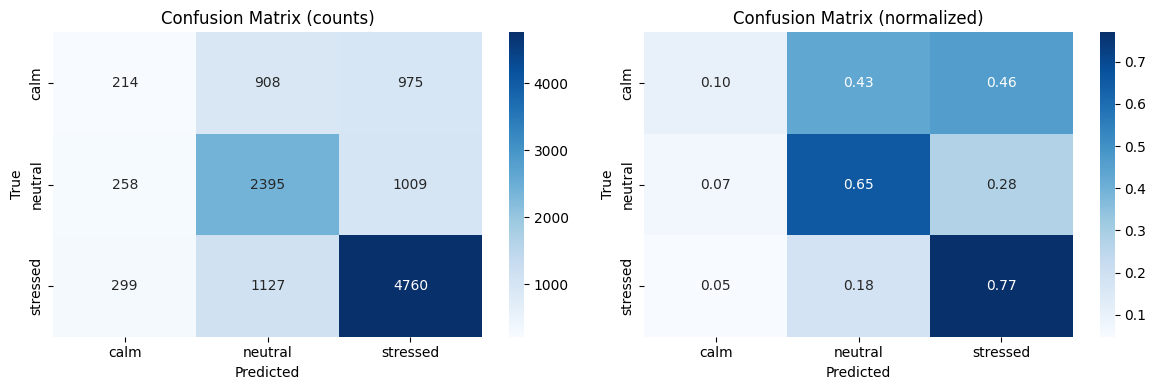

In [32]:
cm = confusion_matrix(all_y, all_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalized)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Feature importance (if supported)

Tree models expose `feature_importances_`. For linear models, you can inspect coefficients, but we only plot importances when available.

In [33]:
# Train the best model on all data, then plot feature importance if available.

best_model = clone(models[best_name])
best_model.fit(X, y)

# Try to extract a feature_importances_ attribute.
importances = None
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "named_steps") and "clf" in getattr(best_model, "named_steps"):
    clf = best_model.named_steps["clf"]
    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_

if importances is None:
    print(f"Model '{best_name}' does not expose feature_importances_. Skipping plot.")
else:
    imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = ["#f4a261" if c in ENG_COLS else "#264653" for c in imp.index]
    imp.plot(kind="barh", ax=ax, color=colors)
    ax.set_title(f"Feature Importance ({best_name})")
    ax.set_xlabel("Importance")
    from matplotlib.patches import Patch

    ax.legend(
        handles=[
            Patch(color="#264653", label="Original feature"),
            Patch(color="#f4a261", label="Engineered feature"),
        ],
        loc="lower right",
    )
    plt.tight_layout()
    plt.show()

Model 'linear_svc' does not expose feature_importances_. Skipping plot.


## 7. Save best model

We retrain the selected best model on **all** data and save a bundle for inference.

In [34]:
# Retrain best model on ALL data and save
final_model = clone(models[best_name])
final_model.fit(X, y)

bundle = {
    "model": final_model,
    "feature_cols": FEATURE_COLS,
    "label_encoder": le,
    "label_col": "label_3class",
    "best_model_name": best_name,
    "cv_macro_f1": float(best_out["macro_f1"]),
    "cv_balanced_acc": float(best_out["balanced_acc"]),
    "cv_accuracy": float(best_out["accuracy"]),
    "notes": "Best-of-models benchmark with GroupCV; trained on model_ready.csv + engineered features",
}

joblib.dump(bundle, "best_model_optimized.joblib")
print("Saved best_model_optimized.joblib")
print("Best model:", bundle["best_model_name"])
print(f"CV Macro F1: {bundle['cv_macro_f1']:.4f}")
print(f"CV Balanced Acc: {bundle['cv_balanced_acc']:.4f}")
print(f"CV Accuracy: {bundle['cv_accuracy']:.4f}")

Saved best_model_optimized.joblib
Best model: linear_svc
CV Macro F1: 0.5061
CV Balanced Acc: 0.5107
CV Accuracy: 0.5850


## 8. Inference Example

In [35]:
# Load and use the saved model
bundle = joblib.load("best_model_optimized.joblib")
loaded_model = bundle["model"]
feat_cols = bundle["feature_cols"]
label_enc = bundle["label_encoder"]

# Example: predict on first 5 rows
sample = df[feat_cols].fillna(0).head(5)
X_s = sample.to_numpy(dtype=float)

preds = loaded_model.predict(X_s)

# Some models may not support predict_proba
if hasattr(loaded_model, "predict_proba"):
    proba = loaded_model.predict_proba(X_s)
    proba_df = pd.DataFrame(proba, columns=[f"p_{c}" for c in label_enc.classes_])
else:
    proba_df = pd.DataFrame({})

result = pd.DataFrame({
    "true": df["label_3class"].head(5).values,
    "predicted": label_enc.inverse_transform(preds),
})

result = pd.concat([result, proba_df.round(3)], axis=1)
result

,true,predicted
0,neutral,calm
1,neutral,calm
2,neutral,neutral
3,neutral,stressed
4,neutral,stressed


## 9. Further improvements (if you still want higher scores)

- Use `model_ready_windowed_3class.csv` (windowing reduces noise a lot).
- Try group CV by `participant_id` for a stricter generalization test.
- Tune the winning model’s hyperparameters.
- Improve labels: reduce noise in `neutral` (many are effectively `unknown`).
| Per-session z-score normalization | Medium (removes between-person variance) | Low |
| LightGBM / XGBoost with careful tuning | Small | Medium |
| Temporal features (rolling mean/std per session) | Medium | Medium |
| Train separate binary classifiers (OvR) | Small | Low |
| Deep learning (LSTM / 1D-CNN) if more data collected | High | High |

Model Comparison Results:
                 Model  Accuracy  F1-Score
1        Random Forest  0.905400  0.904449
2        Decision Tree  0.866471  0.866754
3    Gradient Boosting  0.769360  0.757674
0  Logistic Regression  0.651737  0.614912

Detailed Classification Report for Random Forest (Best Model):
              precision    recall  f1-score   support

        calm       0.95      0.77      0.85       419
     neutral       0.86      0.91      0.88       733
    stressed       0.92      0.95      0.94      1237

    accuracy                           0.91      2389
   macro avg       0.91      0.88      0.89      2389
weighted avg       0.91      0.91      0.90      2389



/var/folders/l6/18hkcypx601_spb15xn_ptr40000gn/T/ipykernel_53733/3569556387.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1-Score', y='Model', data=results_df, palette='viridis')


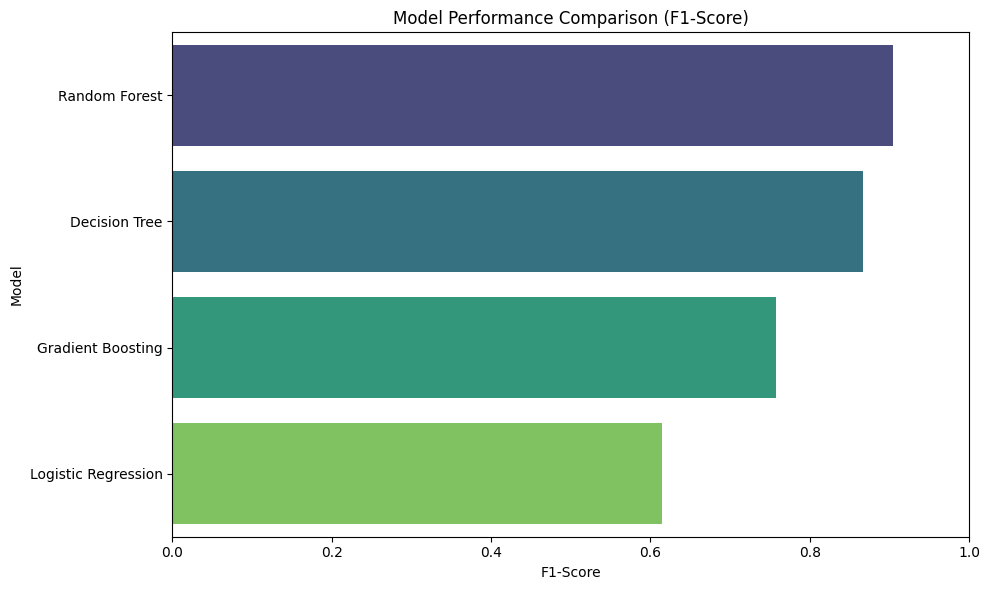

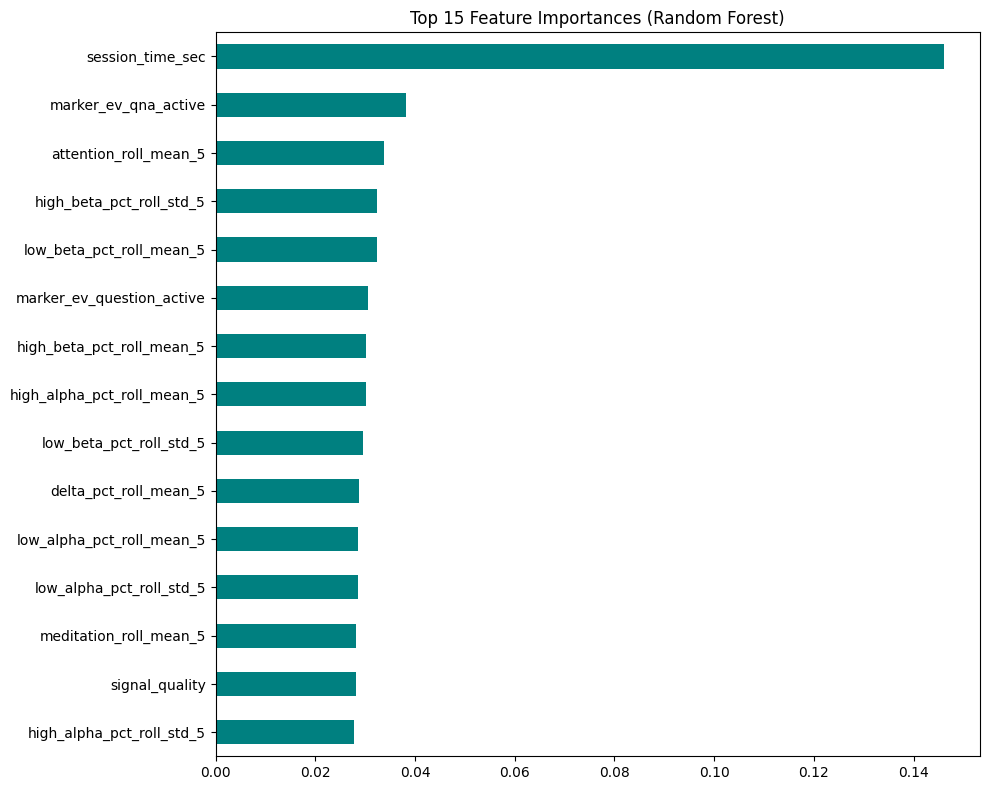

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the featured dataset
df = pd.read_csv('featured_mindtune.csv')

# Define features and target
# Exclude identifiers and the string label
drop_cols = ['session_id', 'participant_id', 'timestamp_ms', 'label_3class', 'label_encoded']
X = df.drop(columns=drop_cols)
y = df['label_encoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, solver="lbfgs", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    # Use scaled data for LogReg, raw data for others
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    trained_models[name] = model
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

print("Model Comparison Results:")
print(results_df)

# Plotting the results
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score', y='Model', data=results_df, palette='viridis')
plt.title('Model Performance Comparison (F1-Score)')
plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig('model_comparison.png')

# Detailed report for the best model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

if best_model_name == "Logistic Regression":
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

print(f"\nDetailed Classification Report for {best_model_name} (Best Model):")
print(classification_report(y_test, y_pred_best, target_names=['calm', 'neutral', 'stressed']))

# Feature Importance for the best tree-based model (if applicable)
if best_model_name in ["Random Forest", "Gradient Boosting", "Decision Tree"]:
    importances = best_model.feature_importances_
    feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 8))
    feat_importances.sort_values().plot(kind='barh', color='teal')
    plt.title(f'Top 15 Feature Importances ({best_model_name})')
    plt.tight_layout()
    plt.savefig('feature_importance.png')

/Users/nirajkarki/mindtune_realtime_classifier/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Error training QDA: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
Extended Model Comparison Results:
                   Model  Accuracy  F1-Score
1            Extra Trees  0.915446  0.914787
0          Random Forest  0.905400  0.904449
2          Decision Tree  0.866471  0.866754
5       MLP (Neural Net)  0.830054  0.829932
3    K-Nearest Neighbors  0.796986  0.797622
4      Gradient Boosting  0.769360  0.757674
7    Logistic Regression  0.651737  0.614912
9                    LDA  0.650063  0.612464
6             Linear SVC  0.654249  0.600103
10              AdaBoost  0.660527  0.598357
12        SGD Classifier  0.626203  0.591218
8       Ridge Classifier  0.646296  0.589938
11  Gaussian Naive Bayes  0.497279  0.457433

Top Performer: Extra Trees
              precision    recall  f1-score   support

        calm       0.96      0.80      0.87       419
     neutral       0.87      0.92      0.89       733
    stresse

/var/folders/l6/18hkcypx601_spb15xn_ptr40000gn/T/ipykernel_53733/87402235.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1-Score', y='Model', data=results_df, palette='magma')


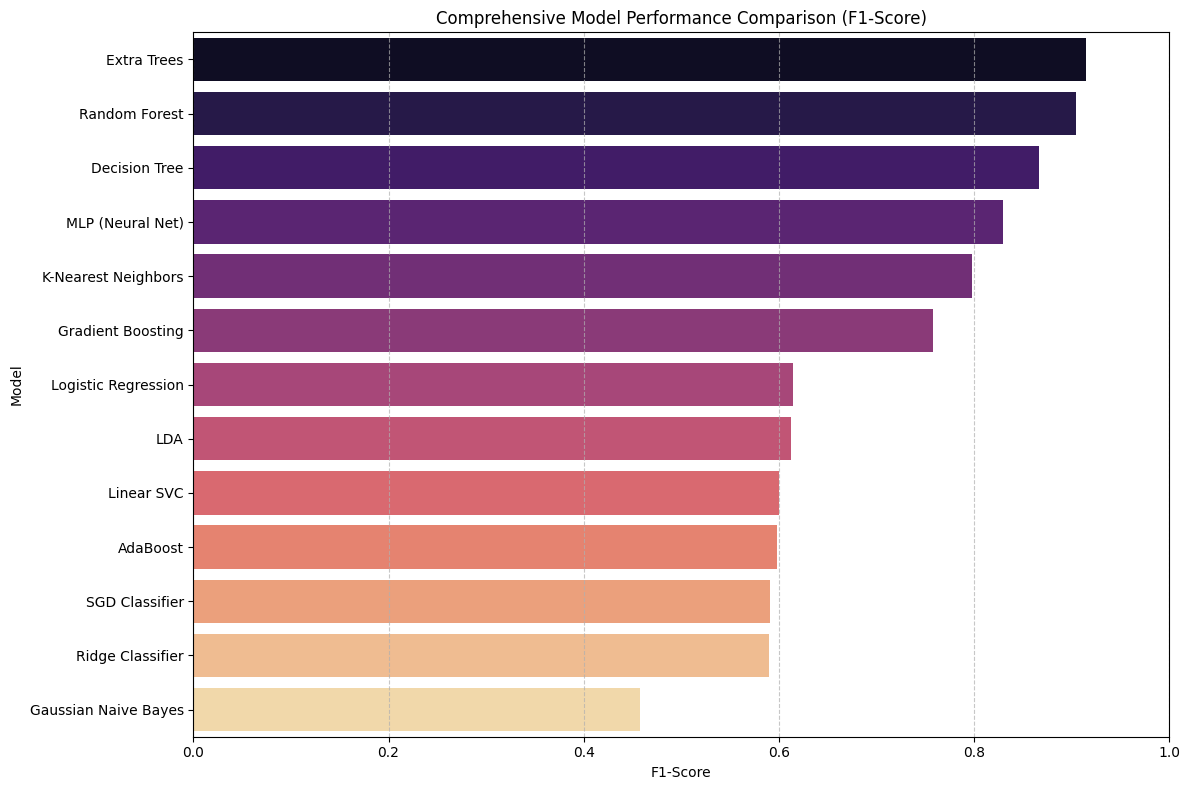

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Importing more models
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Load the featured dataset
df = pd.read_csv('featured_mindtune.csv')

# Define features and target
drop_cols = ['session_id', 'participant_id', 'timestamp_ms', 'label_3class', 'label_encoded']
X = df.drop(columns=drop_cols)
y = df['label_encoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling features (Required for many models like KNN, SVM, MLP, LogReg)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define an extensive list of models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "MLP (Neural Net)": MLPClassifier(max_iter=500, random_state=42),
    "Linear SVC": LinearSVC(max_iter=2000, random_state=42, dual=False),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Ridge Classifier": RidgeClassifier(random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "SGD Classifier": SGDClassifier(random_state=42)
}

results = []
trained_models = {}

# Iterate through models
for name, model in models.items():
    # Use scaled data for models sensitive to scale
    needs_scaling = ["K-Nearest Neighbors", "Linear SVC", "Logistic Regression", 
                     "Ridge Classifier", "MLP (Neural Net)", "SGD Classifier", "LDA", "QDA"]
    
    X_train_to_use = X_train_scaled if name in needs_scaling else X_train
    X_test_to_use = X_test_scaled if name in needs_scaling else X_test
    
    try:
        model.fit(X_train_to_use, y_train)
        y_pred = model.predict(X_test_to_use)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})
        trained_models[name] = model
    except Exception as e:
        print(f"Error training {name}: {e}")

# Compile and sort results
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
results_df.to_csv('extended_model_comparison.csv', index=False)

print("Extended Model Comparison Results:")
print(results_df)

# Plotting the results
plt.figure(figsize=(12, 8))
sns.barplot(x='F1-Score', y='Model', data=results_df, palette='magma')
plt.title('Comprehensive Model Performance Comparison (F1-Score)')
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('extended_comparison_plot.png')

# Detailed report for the top model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
needs_scaling = ["K-Nearest Neighbors", "Linear SVC", "Logistic Regression", "Ridge Classifier", "MLP (Neural Net)", "SGD Classifier", "LDA", "QDA"]
X_test_best = X_test_scaled if best_model_name in needs_scaling else X_test
y_pred_best = best_model.predict(X_test_best)

print(f"\nTop Performer: {best_model_name}")
print(classification_report(y_test, y_pred_best, target_names=['calm', 'neutral', 'stressed']))

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Plotting is optional (comment out if you don't have these installed)
import matplotlib.pyplot as plt
import seaborn as sns

# Importing more models
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Optional boosters (install if missing):
#   python3 -m pip install xgboost lightgbm
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None

# Load the featured dataset
df = pd.read_csv("featured_mindtune.csv")

# Define features and target
drop_cols = ["session_id", "participant_id", "timestamp_ms", "label_3class", "label_encoded"]
X = df.drop(columns=drop_cols)
y = df["label_encoded"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling features (Required for many models like KNN, SVM, MLP, LogReg)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=600, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=25),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "MLP (Neural Net)": MLPClassifier(max_iter=800, random_state=42),
    "Linear SVC": LinearSVC(max_iter=8000, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    "Ridge Classifier": RidgeClassifier(random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "Gaussian Naive Bayes": GaussianNB(),
    "SGD Classifier": SGDClassifier(random_state=42),
}

if XGBClassifier is not None:
    models["XGBoost"] = XGBClassifier(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )

if LGBMClassifier is not None:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
    )

results = []
trained_models = {}

needs_scaling = {
    "K-Nearest Neighbors",
    "Linear SVC",
    "Logistic Regression",
    "Ridge Classifier",
    "MLP (Neural Net)",
    "SGD Classifier",
    "LDA",
    "QDA",
}

for name, model in models.items():
    X_train_to_use = X_train_scaled if name in needs_scaling else X_train
    X_test_to_use = X_test_scaled if name in needs_scaling else X_test

    try:
        model.fit(X_train_to_use, y_train)
        y_pred = model.predict(X_test_to_use)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")
        results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})
        trained_models[name] = model
    except Exception as e:
        print(f"Error training {name}: {e}")

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
X_test_best = X_test_scaled if best_model_name in needs_scaling else X_test
y_pred_best = best_model.predict(X_test_best)

print(f"\nTop Performer: {best_model_name}")
print(classification_report(y_test, y_pred_best, target_names=["calm", "neutral", "stressed"]))

Error training QDA: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
                   Model  Accuracy  F1-Score
1            Extra Trees  0.915446  0.914714
0          Random Forest  0.909167  0.908207
2          Decision Tree  0.866471  0.866754
6       MLP (Neural Net)  0.830054  0.828930
4      Gradient Boosting  0.799079  0.793078
3    K-Nearest Neighbors  0.729175  0.725240
5               AdaBoost  0.667643  0.626375
8    Logistic Regression  0.651737  0.614912
10                   LDA  0.650063  0.612464
7             Linear SVC  0.654249  0.600103
12        SGD Classifier  0.626203  0.591218
9       Ridge Classifier  0.646296  0.589938
11  Gaussian Naive Bayes  0.497279  0.457433

Top Performer: Extra Trees
              precision    recall  f1-score   support

        calm       0.96      0.79      0.87       419
     neutral       0.87      0.91      0.89       733
    stressed       0.93      0.96      0.94   

In [5]:
import joblib
joblib.dump(best_model, 'extra_trees_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']